# AIML with Applied Mathematics — Lab Program 2

## Probability, Bayes, MLE and MAP

**CO Mapping:** CO1

This notebook is prepared for direct execution in **Google Colab**. Run the installation cell first, then run the program cell.

### 1. Install required packages

In [4]:
!pip install -q numpy pandas matplotlib scipy


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. Execute the complete lab program

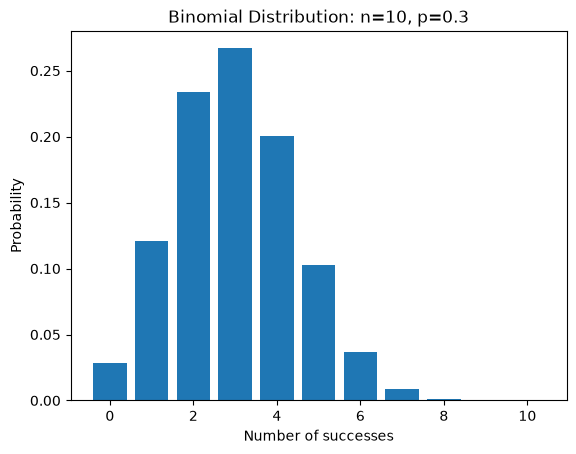

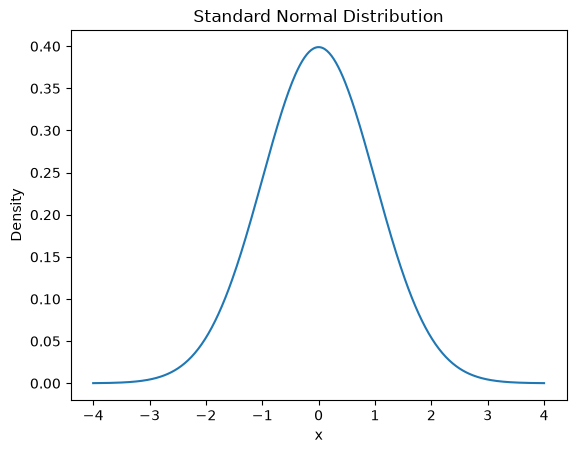

BAYES THEOREM
P(Alert) = 0.059000000000000004
P(Fraud | Alert) = 0.16101694915254236

MLE
Observations: [1 1 1 1 1 1 1 0 0 0]
MLE for Bernoulli p = 0.7


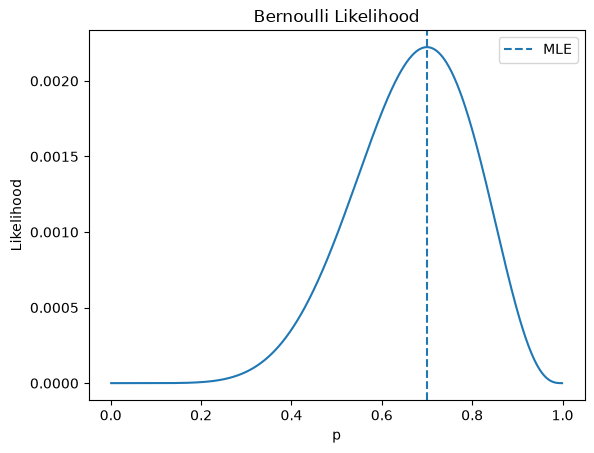


MAP
Prior: Beta(2,2)
Posterior: Beta(9, 5)
MAP estimate = 0.6666666666666666
Posterior mean = 0.6428571428571429


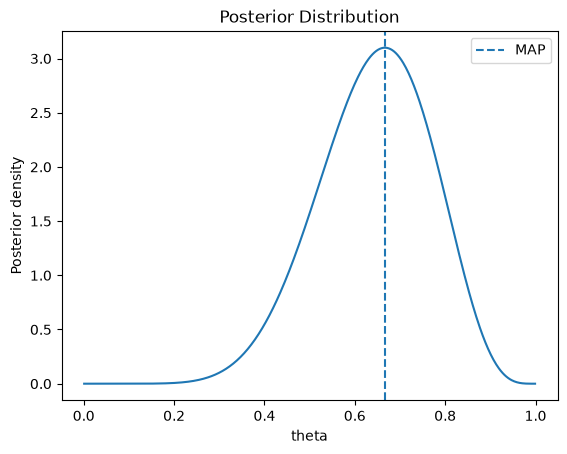

In [6]:

"""
LAB PROGRAM 2
Probability distributions, Bayes theorem, MLE and MAP estimation.
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm, beta

# ---------------- 1. Distributions ----------------
x = np.arange(0, 11)
binomial_probs = binom.pmf(x, n=10, p=0.3)

plt.figure()
plt.bar(x, binomial_probs)
plt.xlabel("Number of successes")
plt.ylabel("Probability")
plt.title("Binomial Distribution: n=10, p=0.3")
plt.show()

z = np.linspace(-4, 4, 400)
plt.figure()
plt.plot(z, norm.pdf(z, 0, 1))
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Standard Normal Distribution")
plt.show()

# ---------------- 2. Bayes theorem ----------------
# Fraud example
P_F = 0.01
P_A_given_F = 0.95
P_A_given_notF = 0.05

P_A = P_A_given_F*P_F + P_A_given_notF*(1-P_F)
P_F_given_A = P_A_given_F*P_F/P_A

print("BAYES THEOREM")
print("P(Alert) =", P_A)
print("P(Fraud | Alert) =", P_F_given_A)

# ---------------- 3. MLE ----------------
# Bernoulli: 7 successes out of 10
data = np.array([1,1,1,1,1,1,1,0,0,0])
p_mle = data.mean()

print("\nMLE")
print("Observations:", data)
print("MLE for Bernoulli p =", p_mle)

# Verify by evaluating likelihood on a grid
p_grid = np.linspace(0.001, 0.999, 500)
likelihood = np.array([
    np.prod(p**data * (1-p)**(1-data)) for p in p_grid
])

plt.figure()
plt.plot(p_grid, likelihood)
plt.axvline(p_mle, linestyle="--", label="MLE")
plt.xlabel("p")
plt.ylabel("Likelihood")
plt.legend()
plt.title("Bernoulli Likelihood")
plt.show()

# ---------------- 4. MAP with Beta prior ----------------
# Prior Beta(2,2)
alpha, beta_prior = 2, 2
successes, failures = 7, 3

post_alpha = alpha + successes
post_beta = beta_prior + failures

map_estimate = (post_alpha-1)/(post_alpha+post_beta-2)
posterior_mean = post_alpha/(post_alpha+post_beta)

print("\nMAP")
print("Prior: Beta(2,2)")
print("Posterior: Beta({}, {})".format(post_alpha, post_beta))
print("MAP estimate =", map_estimate)
print("Posterior mean =", posterior_mean)

theta = np.linspace(0.001, 0.999, 500)
plt.figure()
plt.plot(theta, beta.pdf(theta, post_alpha, post_beta))
plt.axvline(map_estimate, linestyle="--", label="MAP")
plt.legend()
plt.xlabel("theta")
plt.ylabel("Posterior density")
plt.title("Posterior Distribution")
plt.show()


### 3. Student observations

- Record the important outputs/plots generated above.
- Change at least one parameter and rerun the experiment.
- Compare the new result with the original result.
- Record the inference in the lab record.